# Exercice 2 - Entraînez un agent avec une table de décision (Q-table
## Etape 1 : Préparer l'environnement et la Q-table

In [1]:
import gymnasium as gym
import numpy as np
import warnings

# Créer l'environnement
env = gym.make("FrozenLake-v1", render_mode="rgb_array")

# Afficher les espaces d'observation et d'action
print("Espace d'observation :", env.observation_space)
print("Espace d'action :", env.action_space)

# Obtenir dynamiquement les dimensions nécessaires pour la Q-table
num_states = env.observation_space.n
num_actions = env.action_space.n

# Initialiser la Q-table avec des zéros
q_table = np.zeros((num_states, num_actions))

print("\nDimensions de la Q-table :")
print("Nombre d'états :", num_states)
print("Nombre d'actions :", num_actions)
print("\nQ-table initiale (remplie de zéros) :")
print(q_table)


# Masque l'avertissement spécifique à pkg_resources
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

Espace d'observation : Discrete(16)
Espace d'action : Discrete(4)

Dimensions de la Q-table :
Nombre d'états : 16
Nombre d'actions : 4

Q-table initiale (remplie de zéros) :
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Etape 2 : Implémenter la boucle de Q-Learning

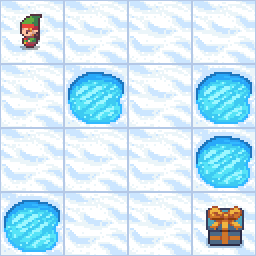

In [2]:
import imageio
from IPython.display import Image, display

# Définition des hyperparamètres
total_episodes = 10000        # Nombre total d'épisodes d'entraînement
learning_rate = 0.8           # Alpha : vitesse d'apprentissage
gamma = 0.95                  # Facteur de réduction (discount factor)
epsilon = 1.0                 # Taux d'exploration initial
max_epsilon = 1.0             # Epsilon max au début
min_epsilon = 0.01            # Epsilon min (exploration résiduelle)
decay_rate = 0.005            # Vitesse de réduction de l'exploration
rewards = []

# Liste pour stocker les images du GIF
frames = []

for episode in range(total_episodes):
    state, info = env.reset()
    done = False
    total_rewards = 0
    
    # Capturer les images uniquement pour certains épisodes (exemple : tous les 1000)
    capture_frames = (episode % 1000 == 0)
    
    while not done:
        use_q_table_rand = np.random.uniform(0, 1)
        if use_q_table_rand > epsilon:
            action = np.argmax(q_table[state, :])
        else:
            action = env.action_space.sample()
        
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Mise à jour Q-table : formule de Bellman
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
        )
        
        total_rewards += reward
        state = new_state
        
        # Capturer l'image de l'environnement si demandé
        if capture_frames:
            frame = env.render()
            frames.append(frame)
    
    # Réduction epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_rewards)

env.close()

# Sauvegarder le GIF
gif_filename = "frozenlake_training.gif"
imageio.mimsave(gif_filename, frames, fps=10)
display(Image(filename="frozenlake_training.gif"))

## Etape3 : Evaluer l'agent

In [3]:
total_test_episodes = 100    # On teste sur 100 parties
total_wins = 0               # Compteur de victoires

for episode in range(total_test_episodes):
    state, info = env.reset()
    done = False

    while not done:
        # PLUS DE HASARD : On prend toujours la meilleure action de la Q-table
        action = np.argmax(q_table[state, :])
        
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Si la récompense est de 1, c'est une victoire !
        if reward == 1.0:
            total_wins += 1

# Calcul et affichage du taux de réussite
success_rate = (total_wins / total_test_episodes) * 100
print(f"Évaluation terminée sur {total_test_episodes} épisodes.")
print(f"Taux de réussite : {success_rate}%")

Évaluation terminée sur 100 épisodes.
Taux de réussite : 74.0%
